In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [1]:
# Célula 1 — setup (roda uma vez)
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained(
    "meta-llama/Llama-3.2-1B",
)

print("Número de camadas:", model.cfg.n_layers)
print("Tamanho do d_model:", model.cfg.d_model)

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
Número de camadas: 16
Tamanho do d_model: 2048


In [2]:
frase = "The city of Tokyo is in Japan."
tokens = model.to_tokens(frase, prepend_bos=True)
nomes  = model.to_str_tokens(frase, prepend_bos=True)

In [4]:
print(f"Total de tokens: {tokens.shape[1]}\n")
for i, (id_, nome) in enumerate(zip(tokens[0], nomes)):
    print(f"  posição {i:2d}  id={int(id_):6d}  token={repr(nome)}")

Total de tokens: 9

  posição  0  id=128000  token='<|begin_of_text|>'
  posição  1  id=   791  token='The'
  posição  2  id=  3363  token=' city'
  posição  3  id=   315  token=' of'
  posição  4  id= 27286  token=' Tokyo'
  posição  5  id=   374  token=' is'
  posição  6  id=   304  token=' in'
  posição  7  id=  6457  token=' Japan'
  posição  8  id=    13  token='.'


In [6]:
frase = "The city of Tokyo is in Japan."

tokens = model.to_tokens(frase, prepend_bos=True)
ultima_posicao = tokens.shape[1] - 1

with torch.no_grad():
    _, cache = model.run_with_cache(tokens)

ativacao = cache["blocks.8.hook_resid_post"][0, ultima_posicao, :]

print("Posição monitorada:", ultima_posicao)
print("Shape da ativação:", ativacao.shape)
print("Primeiros 10 valores:", ativacao[:10])

Posição monitorada: 8
Shape da ativação: torch.Size([2048])
Primeiros 10 valores: tensor([ 0.0734,  0.1672,  0.1961, -0.0195,  0.0656, -0.0069,  0.0203, -0.0021,
        -0.2531, -0.0145])


In [8]:
frases = [
    ("The city of Tokyo is in Japan.", 1),   # verdadeira
    ("The city of Tokyo is in France.", 0),  # falsa
]

ativacoes = []
for frase, label in frases:
    tokens = model.to_tokens(frase, prepend_bos=True)
    ultima_posicao = tokens.shape[1] - 1
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    atv = cache["blocks.8.hook_resid_post"][0, ultima_posicao, :]
    ativacoes.append(atv.float().numpy())
    print(f"label={label}  frase='{frase}'")

# distância entre os dois vetores
diff = ativacoes[0] - ativacoes[1]
distancia = np.linalg.norm(diff)
similaridade = np.dot(ativacoes[0], ativacoes[1]) / (
    np.linalg.norm(ativacoes[0]) * np.linalg.norm(ativacoes[1])
)

print(f"\nDistância L2:        {distancia:.4f}")
print(f"Cosine similarity:   {similaridade:.4f}")

label=1  frase='The city of Tokyo is in Japan.'
label=0  frase='The city of Tokyo is in France.'

Distância L2:        1.9239
Cosine similarity:   0.9436


In [9]:
pares = [
    ("The city of Tokyo is in Japan.", 1),
    ("The city of Tokyo is in France.", 0),
    ("The city of Paris is in France.", 1),
    ("The city of Paris is in Brazil.", 0),
    ("The city of Berlin is in Germany.", 1),
    ("The city of Berlin is in Japan.", 0),
    ("The city of Cairo is in Egypt.", 1),
    ("The city of Cairo is in Germany.", 0),
]

ativacoes_true = []
ativacoes_false = []

for frase, label in pares:
    tokens = model.to_tokens(frase, prepend_bos=True)
    ultima_posicao = tokens.shape[1] - 1
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    atv = cache["blocks.8.hook_resid_post"][0, ultima_posicao, :].float().numpy()
    if label == 1:
        ativacoes_true.append(atv)
    else:
        ativacoes_false.append(atv)

media_true  = np.mean(ativacoes_true, axis=0)
media_false = np.mean(ativacoes_false, axis=0)
direcao_verdade = media_true - media_false

print(f"Frases verdadeiras: {len(ativacoes_true)}")
print(f"Frases falsas:      {len(ativacoes_false)}")
print(f"Shape da direção:   {direcao_verdade.shape}")
print(f"Norma da direção:   {np.linalg.norm(direcao_verdade):.4f}")

Frases verdadeiras: 4
Frases falsas:      4
Shape da direção:   (2048,)
Norma da direção:   1.7751


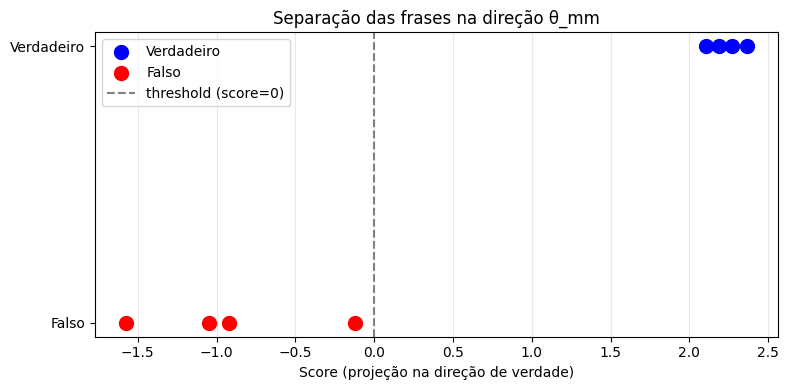

In [11]:
# projetar todas as frases de treino na direção de verdade
scores_true = [np.dot(atv, direcao_verdade) for atv in ativacoes_true]
scores_false = [np.dot(atv, direcao_verdade) for atv in ativacoes_false]

fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(scores_true,  [1]*len(scores_true),  color="blue", s=100, label="Verdadeiro", zorder=3)
ax.scatter(scores_false, [0]*len(scores_false), color="red",  s=100, label="Falso",      zorder=3)

ax.axvline(x=0, color="gray", linestyle="--", label="threshold (score=0)")

ax.set_xlabel("Score (projeção na direção de verdade)")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Falso", "Verdadeiro"])
ax.set_title("Separação das frases na direção θ_mm")
ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
frases_teste = [
    ("The city of London is in United Kingdom.", 1),
    ("The city of London is in Italy.", 0),
    ("The city of Moscow is in Russia.", 1),
    ("The city of Moscow is in China.", 0),
]

print("Testando a direção de verdade:\n")
for frase, label_real in frases_teste:
    tokens = model.to_tokens(frase, prepend_bos=True)
    ultima_posicao = tokens.shape[1] - 1
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    atv = cache["blocks.8.hook_resid_post"][0, ultima_posicao, :].float().numpy()

    score = np.dot(atv, direcao_verdade)
    predicao = 1 if score > 0 else 0
    correto = "✓" if predicao == label_real else "✗"

    print(f"{correto} score={score:+.4f}  label={label_real}  '{frase}'")

Testando a direção de verdade:

✓ score=+2.2603  label=1  'The city of London is in United Kingdom.'
✓ score=-0.7298  label=0  'The city of London is in Italy.'
✓ score=+2.0940  label=1  'The city of Moscow is in Russia.'
✓ score=-1.6358  label=0  'The city of Moscow is in China.'


In [16]:
df = pd.read_csv(r'\Users\carlo\OneDrive\Desktop\geometry-of-truth\data\raw\cities.csv')
print(df.shape)
print(df.head())

(102, 4)
                               statement  label lang dataset
0         The city of Tokyo is in Japan.      1   en  cities
1          The city of Tokyo is in Cuba.      0   en  cities
2       The city of Beijing is in China.      1   en  cities
3  The city of Beijing is in Bangladesh.      0   en  cities
4        The city of Mumbai is in India.      1   en  cities


In [17]:
from tqdm.notebook import tqdm

statements = df["statement"].tolist()
labels = df["label"].values

ativacoes = []

for frase in tqdm(statements, desc="Extraindo ativações"):
    tokens = model.to_tokens(frase, prepend_bos=True)
    ultima_posicao = tokens.shape[1] - 1
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    atv = cache["blocks.8.hook_resid_post"][0, ultima_posicao, :].float().numpy()
    ativacoes.append(atv)

ativacoes = np.stack(ativacoes)  # shape (102, 2048)
print("Shape final:", ativacoes.shape)

Extraindo ativações:   0%|          | 0/102 [00:00<?, ?it/s]

Shape final: (102, 2048)


PC1 explica 39.4% da variância
PC2 explica 21.3% da variância


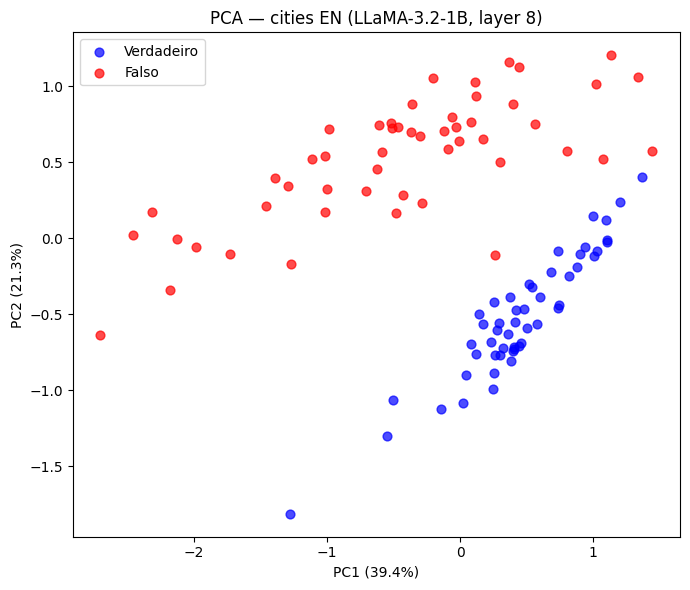

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# centralizar as ativações (subtrair a média geral)
ativacoes_centradas = ativacoes - ativacoes.mean(axis=0)

# reduzir de 2048 para 2 dimensões
pca = PCA(n_components=2)
coords = pca.fit_transform(ativacoes_centradas)

variancia = pca.explained_variance_ratio_
print(f"PC1 explica {variancia[0]*100:.1f}% da variância")
print(f"PC2 explica {variancia[1]*100:.1f}% da variância")

# plotar
fig, ax = plt.subplots(figsize=(7, 6))

for label, cor, nome in [(1, "blue", "Verdadeiro"), (0, "red", "Falso")]:
    mask = labels == label
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=cor, label=nome, alpha=0.7, s=40)

ax.set_xlabel(f"PC1 ({variancia[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({variancia[1]*100:.1f}%)")
ax.set_title("PCA — cities EN (LLaMA-3.2-1B, layer 8)")
ax.legend()
plt.tight_layout()
plt.show()

Agora portugues

In [20]:
df_pt = pd.read_csv(r'\Users\carlo\OneDrive\Desktop\geometry-of-truth\data\raw\cidades_br.csv')
print(df_pt.shape)
print(df_pt.head())

(100, 4)
                                           statement  label lang     dataset
0           A cidade de São Paulo fica em São Paulo.      1   pt  cidades_br
1            A cidade de São Paulo fica no Amazonas.      0   pt  cidades_br
2  A cidade de Rio de Janeiro fica no Rio de Jane...      1   pt  cidades_br
3      A cidade de Rio de Janeiro fica em São Paulo.      0   pt  cidades_br
4     A cidade de Brasília fica no Distrito Federal.      1   pt  cidades_br


In [21]:
statements_pt = df_pt["statement"].tolist()
labels_pt = df_pt["label"].values

ativacoes_pt = []

for frase in tqdm(statements_pt, desc="Extraindo ativações PT"):
    tokens = model.to_tokens(frase, prepend_bos=True)
    ultima_posicao = tokens.shape[1] - 1
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    atv = cache["blocks.8.hook_resid_post"][0, ultima_posicao, :].float().numpy()
    ativacoes_pt.append(atv)

ativacoes_pt = np.stack(ativacoes_pt)
print("Shape final:", ativacoes_pt.shape)

Extraindo ativações PT:   0%|          | 0/100 [00:00<?, ?it/s]

Shape final: (100, 2048)


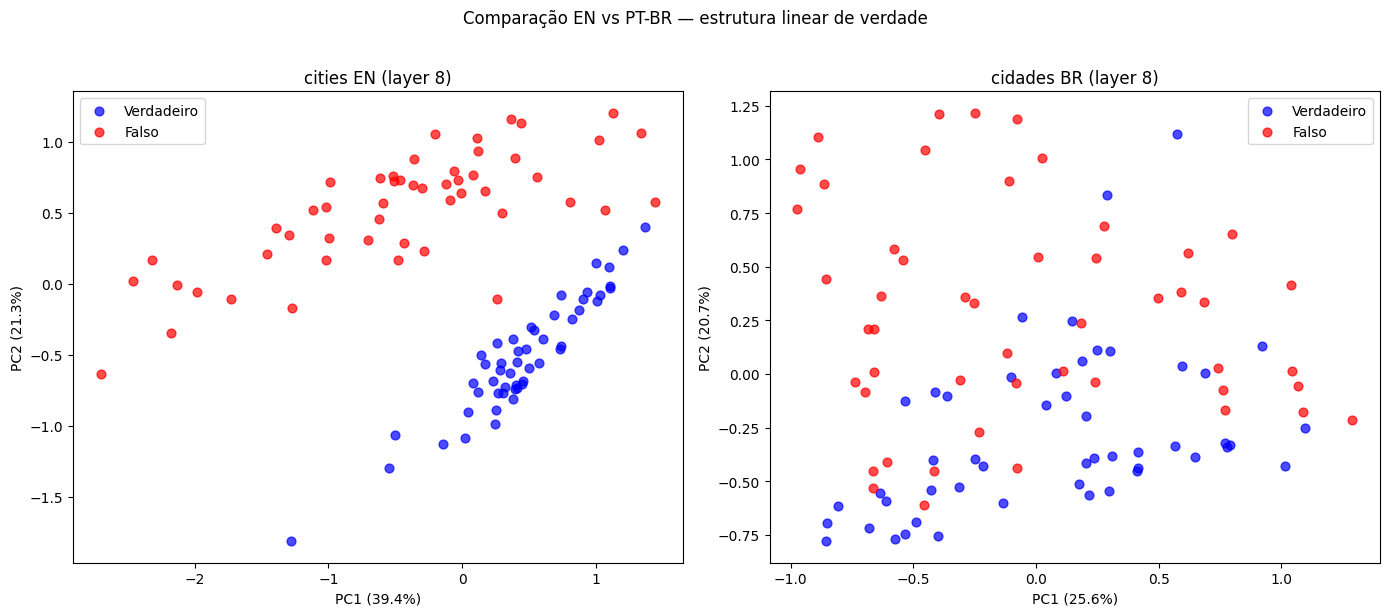

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, ativs, labs, titulo in [
    (axes[0], ativacoes,    labels,    "cities EN (layer 8)"),
    (axes[1], ativacoes_pt, labels_pt, "cidades BR (layer 8)"),
]:
    # centralizar e aplicar PCA
    ativs_centradas = ativs - ativs.mean(axis=0)
    pca = PCA(n_components=2)
    coords = pca.fit_transform(ativs_centradas)
    variancia = pca.explained_variance_ratio_

    for label, cor, nome in [(1, "blue", "Verdadeiro"), (0, "red", "Falso")]:
        mask = labs == label
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=cor, label=nome, alpha=0.7, s=40)

    ax.set_xlabel(f"PC1 ({variancia[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({variancia[1]*100:.1f}%)")
    ax.set_title(titulo)
    ax.legend()

plt.suptitle("Comparação EN vs PT-BR — estrutura linear de verdade", y=1.02)
plt.tight_layout()
plt.show()